# Prior-Data Fitted Networks (part 2)
Now we know how to train a simple PFN for a simple regression tasks. 
In this part we want to focus on getting better priors.

In [1]:
# basic imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
import torch.nn as nn
from torch.nn.modules.transformer import MultiheadAttention

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU:", device)
else:
    device = torch.device("cpu")
    print("No GPU -> using CPU:", device)

No GPU -> using CPU: cpu


## Transformer model

We start with Transfomer architecture for our PFN. The model predicts probability mass function.

In [2]:
class PriorDataLoader(object):
    def __init__(self, get_prior_data_fn, batch_size, num_points_in_each_dataset, seed=0):
        self.batch_size = batch_size
        self.num_points_in_each_dataset = num_points_in_each_dataset
        self.get_prior_data_fn = get_prior_data_fn
        self.epoch = 0
        self.rng = np.random.default_rng(seed)  

        min_samples = 1
        max_samples = self.num_points_in_each_dataset - 1
        self._trainset_sizes = np.arange(min_samples, max_samples)
        self._trainset_weights = 1 / (max_samples - min_samples - np.arange(max_samples - min_samples))
        self._trainset_weights /= self._trainset_weights.sum()  # normalize

    def get_batch(self, train = True, batch_size=None):
        """
        Returns:
            xs, ys, trainset_size
        """
        self.epoch += train
        bs = batch_size if batch_size else self.batch_size
        return self.get_prior_data_fn(bs, self.num_points_in_each_dataset), self._sample_trainset_size()

    def _sample_trainset_size(self):
        # weighted sampling using NumPy RNG
        return self.rng.choice(self._trainset_sizes, p=self._trainset_weights)


class BarDistribution(nn.Module):
    def __init__(self, bucket_limits: torch.Tensor = None):
        super().__init__()

        self.bucket_limits = bucket_limits
        if bucket_limits is not None:
            self.bucket_widths = self.bucket_limits[1:] - self.bucket_limits[:-1]
            self.bucket_means = self.bucket_limits[:-1] + self.bucket_widths / 2

    def set_buckets(self, num_outputs, ys):
        self.bucket_limits = self.get_bucket_limits(num_outputs, ys)
        self.bucket_widths = self.bucket_limits[1:] - self.bucket_limits[:-1]
        self.bucket_means = self.bucket_limits[:-1] + self.bucket_widths / 2

    def get_bucket_limits(self, num_outputs, ys):
        """
        Create bucket borders for y by sorting and splitting into equal parts.
        """
        ys = ys.flatten()
        n = len(ys) - len(ys) % num_outputs
        ys_sorted, _ = ys[:n].sort()
        step = n // num_outputs
        mids = (ys_sorted[step-1::step][:-1] + ys_sorted[step::step]) / 2
        return torch.cat([ys_sorted[:1], mids, ys_sorted[-1:]])


    def y_to_bucket_idx(self, ys):
        """
        Maps the value of y to the corresponding bucket in `bucket_limits`
        """
        target_sample = torch.searchsorted(self.bucket_limits, ys) - 1
        target_sample[ys <= self.bucket_limits[0]] = 0
        target_sample[ys >= self.bucket_limits[-1]] = len(self.bucket_limits) - 1 - 1
        return target_sample
        
    def mean(self, logits):
        p = torch.softmax(logits, dim=-1)
        
        side_normals = (
            self.get_halfnormal_with_p_weight_before(self.bucket_widths[0]),
            self.get_halfnormal_with_p_weight_before(self.bucket_widths[-1])
        )
        self.bucket_means[0] = -side_normals[0].mean + self.bucket_widths[1]
        self.bucket_means[-1] = side_normals[1].mean + self.bucket_widths[-2]

        return p @ self.bucket_means

    def cdf(self, logits, left_prob):
        """
        Computes quantile corresponding to left_prob
        """
        probs = torch.softmax(logits, -1)
        cumprobs = torch.cumsum(probs, -1)
        idx = torch.searchsorted(cumprobs, left_prob * torch.ones(*cumprobs.shape[:-1], 1)).squeeze(-1).clamp(0, cumprobs.shape[-1] - 1)
        cumprobs = torch.cat([torch.zeros(*cumprobs.shape[:-1], 1, device=logits.device), cumprobs], -1)
        
        rest_prob = left_prob - cumprobs.gather(-1, idx[..., None]).squeeze(-1)
        left_border = self.bucket_limits[idx]
        right_border = self.bucket_limits[idx+1]
        return left_border + (right_border - left_border) * rest_prob / probs.gather(-1, idx[..., None]).squeeze(-1)

    def quantile(self, logits, center_prob = 0.682):
        """
        Computes +/- quantiles corresponding to center_prob.
        """
        side_prob = (1.0-center_prob)/2 # center_prob = 0.682 area under the normal function within 1 std
        return torch.stack([self.cdf(logits, side_prob), self.cdf(logits, 1-side_prob)], -1)

    def get_halfnormal_with_p_weight_before(self, range_max, p=0.5):
        """Half-normal scaled so that `p` portion lies within range_max."""
        s = range_max / torch.distributions.HalfNormal(1.).icdf(torch.tensor(p))
        return torch.distributions.HalfNormal(s)

    def forward(self,   logits: torch.Tensor, target_y: torch.Tensor,):
        target_idx =  self.y_to_bucket_idx(target_y)
        widths = self.bucket_limits[1:] - self.bucket_limits[:-1]
        log_probs = torch.log_softmax(logits, -1) - torch.log(widths)
        log_probs = log_probs.gather(-1, target_idx[..., None]).squeeze(-1)

        # Half-normal edge corrections
        left, right = self.get_halfnormal_with_p_weight_before(widths[0]), self.get_halfnormal_with_p_weight_before(widths[-1])
        first, last = target_idx == 0, target_idx == len(widths)-1
        
        if first.any():
            log_probs[first] += (left.log_prob(self.bucket_limits[1]-target_y[first])
                                .clamp(min=1e-8) + torch.log(widths[0]))
        if last.any():
            log_probs[last] += (right.log_prob(target_y[last]-self.bucket_limits[-2])
                                .clamp(min=1e-8) + torch.log(widths[-1]))
        return -log_probs.mean()


class Encoder(nn.Module):
    """Typical self attention module in transformer"""
    def __init__(self, d_model, n_heads, n_hidden, dropout=0.1):
        super().__init__()
        self.self_attn = MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.out = nn.Sequential(
            nn.Linear(d_model, n_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(n_hidden, d_model),
        )
        
        self.dropout = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
    def forward(self, src, trainset_size):
        src_left, src_right = src[:, :trainset_size], src[:, trainset_size:]
        x_left = self.self_attn(src_left, src_left, src_left)[0] # all train points to each other
        x_right = self.self_attn(src_right, src_left, src_left)[0] # test points attend to train points
        x = torch.cat([x_left, x_right], dim=1)
        x = self.norm1(src + self.dropout(x))
        return self.norm2(self.dropout(self.out(x)) + x)


class Transformer(nn.Module):
    def __init__(self, num_features, n_out , criterion, n_layers=2, d_model=512, n_heads=4, n_hidden=1024, dropout=0.0, normalize=lambda x:x):
        super().__init__()
        self.criterion = criterion
        self.x_encoder = nn.Linear(num_features, d_model)
        self.y_encoder = nn.Linear(1, d_model)
        
        self.model = nn.ModuleList(
            [Encoder(d_model, n_heads, n_hidden, dropout) for _ in range(n_layers)]
        )
        
        self.out = nn.Sequential(
            nn.Linear(d_model, n_hidden),
            nn.GELU(),
            nn.Linear(n_hidden, n_out)
        )
                
        self.normalize = normalize
        self.init_weights()
        
    def forward(self, x, y, trainset_size):
        """
        Args:
            x: num_datasets x number_of_points x num_features
            y: num_datasets x number_of_points
            trainset_size: int specifying the number of points to use as training dataset size
        
        Returns:
            outputs for each x
        """
        x_src = self.x_encoder(self.normalize(x))
        y_src = self.y_encoder(y)
        
        src = torch.cat([x_src[:, :trainset_size] + y_src[:, :trainset_size], x_src[:, trainset_size:]], dim=1)
        for encoder in self.model:
            src = encoder(src, trainset_size)

        return self.out(src)
    
    def init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

In [3]:
def train_model(model, optimizer, scheduler, dl, epochs=10, steps_per_epoch=100, validate_epoch=10):
    model.to(device)
    (test_xs, _, test_ys), test_trainset_size = dl.get_batch(False, 64)
    test_xs, test_ys = test_xs.to(device), test_ys.to(device)

    for step in range(epochs * steps_per_epoch + 1):
        (xs, ys, target_y), trainset_size = dl.get_batch()
        xs, ys, target_y = xs.to(device), ys.to(device), target_y.to(device)
        pred_y = model(xs, ys.unsqueeze(-1), trainset_size)
        
        logits = pred_y[:, trainset_size:]
        target_y = target_y[:, trainset_size:].clone().view(*logits.shape[:-1])
        
        loss = model.criterion(logits, target_y)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.)
        optimizer.step()
        scheduler.step()
        
        if step % (validate_epoch * steps_per_epoch) == 0:
            with torch.no_grad():
                pred_test_y = model(test_xs, test_ys.unsqueeze(-1), test_trainset_size)
                logits = pred_test_y[:, test_trainset_size:]
                target_test_y = test_ys[:, test_trainset_size:].clone().view(*logits.shape[:-1])
                val_loss = model.criterion(logits, target_test_y)
                print(f'@Step: {step}\tVal loss:{val_loss.item(): 0.5f}\t lr:{scheduler.get_last_lr()[0]: 0.6e}\t train_loss:{loss.item(): 0.5f}')

## Data Generating Prior

For a Prior-Data Fitted Network (PFN), it's crucial to generate synthetic data based on well-defined priors. In this tutorial, we'll explore a PFN designed to approximate the Posterior Predictive Distribution (PPD), where the model parameters $\theta$ are drawn from a normal distribution centered around the origin.

---

### Bayesian Neural Network (BNN) Prior
A Bayesian Neural Network (BNN) prior requires learning across a variety of neural network architectures. Consider Multilayer Perceptrons (MLPs) with varying hyperparameters, such as network depth, number of hidden units, activation functions, and dropout probabilities. BNNs aim to learn a posterior distribution over these hyperparameters in relation to the dataset. Thus, a BNN is capable of predicting a probable distribution over its outputs, essentially modeling the Posterior Predictive Distribution (PPD). Traditional methods for finding the posterior distribution over these hyperparameters, such as Stochastic Variational Inference (SVI) and Markov Chain Monte Carlo (MCMC), are computationally intensive.

Prior-Data Fitted Networks (PFNs) learn the PPD by utilizing synthetic data generated from MLPs with a range of such hyperparameters. Therefore, it is necessary to define an MLP class that can initialize the architecture as specified by the hyperparameters. This allows for the generation of synthetic data by defining a range of hyperparameters.

<img src='images/bnn.png' width=500px>


In [4]:
import torch
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden_dim, n_layers, act='tanh',
                 init_std=0.1, sparsity=0.0, noise_std=0.0):
        super().__init__()
        activation_map = {'tanh': nn.Tanh(), 'relu': nn.ReLU(), 'elu': nn.ELU(), 'id': nn.Identity()}
        self.activation, self.noise_std, self.sparsity = activation_map[act], noise_std, sparsity
        self.layers = nn.ModuleList(
            [nn.Linear(in_dim, hidden_dim)] +
            [nn.Linear(hidden_dim, hidden_dim) for _ in range(n_layers - 2)] +
            [nn.Linear(hidden_dim, out_dim)]
        )
        self._init(init_std)

    def _init(self, std):
        with torch.no_grad():
            for i, layer in enumerate(self.layers):
                layer.weight.normal_(0, std)
                layer.bias.normal_(0, std)
                if 0 < self.sparsity < 1 and 0 < i < len(self.layers) - 1:
                    mask = torch.bernoulli(torch.full_like(layer.weight, 1 - self.sparsity))
                    layer.weight.mul_(mask / (1 - self.sparsity) ** 0.5)

    def forward(self, x):
        for layer in self.layers[:-1]:
            x = layer(x)
            x = x + torch.randn_like(x) * self.noise_std
            x = self.activation(x)
        return self.layers[-1](x)


In [5]:
import torch, numpy as np

def generate_bnn_prior(n_datasets=10, n_features=1, n_points=100, hparams=None):
    xs = torch.randn(n_datasets, n_points, n_features)
    mk_mlp = lambda noise: MLP(
        in_dim=n_features, out_dim=1,
        hidden_dim=hparams['mlp_num_hidden'],
        n_layers=hparams['mlp_num_layers'],
        init_std=hparams['mlp_init_std'],
        sparsity=hparams['mlp_sparseness'],
        noise_std=noise,
        act=hparams['mlp_activation']
    )
    model, clean_model = mk_mlp(hparams['mlp_preactivation_noise_std']), mk_mlp(0)

    ys, targets = [], []
    for x in xs:
        model._init(hparams['mlp_init_std'])
        x = x / np.sqrt(n_features)
        with torch.no_grad():
            y = model(x)
            ys.append(y[None])
            clean_model.load_state_dict(model.state_dict())
            targets.append(clean_model(x)[None])

    ys, targets = torch.cat(ys).squeeze(-1), torch.cat(targets).squeeze(-1)
    ys_noisy = ys + torch.randn_like(ys) * hparams['mlp_output_noise']
    return xs, ys_noisy, targets


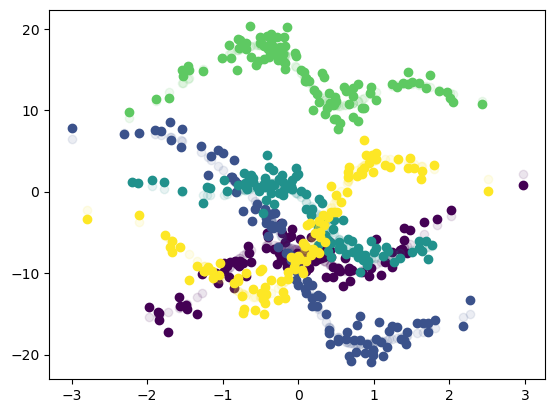

In [6]:
hyperparameters = {
    'mlp_num_layers': 2, 
    'mlp_num_hidden': 512,
    'mlp_init_std': 1.0, 
    'mlp_sparseness': 0.1, 
    'mlp_output_noise': 0.1,
    'mlp_preactivation_noise_std': 0.1,
    'mlp_activation': 'tanh'
}
num_datasets = 5
colors = mpl.colormaps.get_cmap('viridis').resampled(num_datasets).colors


xs, ys, target_ys = generate_bnn_prior(n_datasets=num_datasets, hparams=hyperparameters)
for dataset_index in range(num_datasets):
    color = colors[dataset_index].reshape(1,-1)
    plt.scatter(xs[dataset_index], ys[dataset_index], c=color)
    plt.scatter(xs[dataset_index], target_ys[dataset_index], c=color, alpha=0.1)

In [7]:
from transformers import get_cosine_schedule_with_warmup
# Parameters related to prior data
num_features = 5
num_outputs = 20
num_points_in_each_dataset = 30
max_num_datasets = 16

prior_hyperparameters = {
    'mlp_num_layers': 2, 
    'mlp_num_hidden': 64,
    'mlp_init_std': 1.0, 
    'mlp_sparseness': 0.1, 
    'mlp_output_noise': 1.0,
    'mlp_preactivation_noise_std': 1.0,
    'mlp_activation': 'tanh',
}


_, ys,  _ = generate_bnn_prior(n_datasets = 100000, n_features = num_features, hparams = prior_hyperparameters)
criterion = BarDistribution()
criterion.set_buckets(num_outputs, ys)


# training data
get_prior_data_fn = lambda x, y: generate_bnn_prior(x, num_features, y, prior_hyperparameters)
dl = PriorDataLoader(get_prior_data_fn, batch_size=max_num_datasets, num_points_in_each_dataset=num_points_in_each_dataset)
# Models
model = Transformer(criterion=criterion, num_features=num_features, n_out=num_outputs, d_model=16, n_layers=4, n_hidden=32, n_heads=4)

# Learning
epochs = 20
steps_per_epoch = 100
warmup_epochs = epochs // 4
validate_epoch = 5
lr = 0.001
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_epochs * steps_per_epoch, epochs * steps_per_epoch)
train_model(model, optimizer, scheduler, dl, epochs, steps_per_epoch, validate_epoch)



/home/amir/anaconda3/envs/tabPFN/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


@Step: 0	Val loss: 3.44312	 lr: 2.000000e-06	 train_loss: 3.25169
@Step: 500	Val loss: 2.58524	 lr: 9.999989e-04	 train_loss: 2.94434
@Step: 1000	Val loss: 2.33546	 lr: 7.490926e-04	 train_loss: 2.45754
@Step: 1500	Val loss: 2.30800	 lr: 2.490936e-04	 train_loss: 2.59153
@Step: 2000	Val loss: 2.28103	 lr: 1.096622e-09	 train_loss: 2.73034


## Compute metrics and visualize

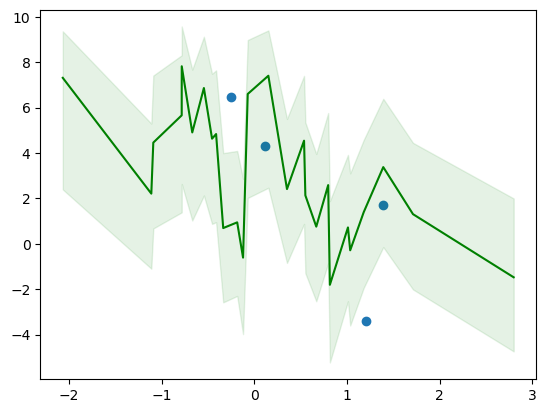

In [22]:
import sklearn

(xs,_, ys), num_training_points = dl.get_batch()

batch_index = 0
num_training_points = 4 # this is the trainset_size

xs_train = xs[batch_index, :num_training_points]
ys_train = ys[batch_index, :num_training_points]
xs_test = xs[batch_index, num_training_points:]

with torch.no_grad():
    logits = model(xs.to(device), ys.unsqueeze(-1).to(device), num_training_points)

# predicted means from a bar distribution
test_logits = logits[batch_index, num_training_points:].cpu()
pred_means = model.criterion.mean(test_logits)
pred_confs = model.criterion.quantile(test_logits)

# plot pfn
plt.scatter(xs_train[..., 0], ys_train)
order_test_x = xs_test[..., 0].argsort()
plt.plot(xs_test[order_test_x, 0], pred_means[order_test_x], color='green', label='pfn')
plt.fill_between(xs_test[order_test_x, 0], pred_confs[order_test_x, 0], pred_confs[order_test_x, 1], alpha=0.1, color='green')


### Structural Causal Model (SCM) Prior
Causal reasoning involves estimating the causal graphs (Directed Acyclic Graphs, DAGs) that model the inputs and their impacts on the outputs. These causal relationships are identified through the use of observational data and interventions. While previous works have focused on identifying a single SCM, the authors note that this approach can be problematic, as most SCMs are not unique in the absence of intervention data.
Defining an SCM prior is similar to defining a Bayesian Neural Network (BNN) prior, except that we randomly select intermediate nodes for xs and ys.

<img src='images/scm.png' width=500px>

In [132]:
class SCM(nn.Module):
    ACTIVATIONS = {
        'tanh': nn.Tanh(),
        'relu': nn.ReLU(),
        'elu': nn.ELU(),
        'identity': nn.Identity(),
    }
    
    def __init__(self, num_outputs, num_features, hyperparameters={}):
        super(SCM, self).__init__()
        
        self.num_outputs = num_outputs
        self.num_features = num_features
        self.num_causes = hyperparameters['num_causes']
        
        n_layers = hyperparameters['num_layers']
        hidden_dim = hyperparameters['hidden_dim'] 
        
        self.layers = nn.Sequential(
            nn.Linear(self.num_causes, hidden_dim),
            *[nn.Linear(hidden_dim, hidden_dim) for _ in range(n_layers-2)],
            nn.Linear(hidden_dim, hyperparameters['num_mlp_outputs'])
        )
        
        self.activation = self.ACTIVATIONS[hyperparameters['activation']]
        self.output_noise = hyperparameters['output_noise'] # noise in intermediate activations
        self.y_is_effect = hyperparameters['y_is_effect']
        
        # dropping out connections 
        dropout_prob = max(0.01, hyperparameters['dropout'])
        init_std = hyperparameters['init_std']
        for n, p in self.layers.named_parameters():
            if p.shape == 2: # only to weights
                nn.init.normal_(p, std=init_std)
                p *= torch.bernoulli(torch.zeros_like(p) + 1. - dropout_prob)

    @torch.no_grad
    def forward(self, causes):
        num_datasets = causes.shape[0]
        outputs = [causes]
        for layer in self.layers[:-1]:
            causes = layer(outputs[-1])
            causes = self.activation(causes)
            causes = causes + torch.normal(torch.zeros_like(causes), self.output_noise)
            outputs.append(causes)
        
        final_output = self.layers[-1](outputs[-1])
        outputs.append(final_output + torch.normal(torch.zeros_like(final_output), self.output_noise))
        
        outputs, no_noise_outputs = outputs[1:], final_output[1:]
        outputs = torch.cat(outputs, -1)
        
        # selecting x and y for synthetic data
        random_perm = [torch.randperm(outputs.shape[-1]-1, device=device).unsqueeze(0) for _ in range(num_datasets)]
        random_perm = torch.cat(random_perm, 0)
        
        # selection of outputs
        if self.y_is_effect:
            random_idx_y = list(range(-self.num_outputs, -0))
            noisy_ys = outputs[..., random_idx_y]
        else:
            random_idx_y = random_perm[..., :self.num_outputs]
            random_idx_y = random_idx_y.unsqueeze(1).expand(-1, outputs.shape[1], -1)
            noisy_ys = torch.gather(outputs, -1, random_idx_y)
            
        # selection of inputs, i.e., num_features
        random_idx_x = random_perm[..., self.num_outputs:self.num_outputs + self.num_features]
        random_idx_x = random_idx_x.unsqueeze(1).expand(-1, outputs.shape[1], -1)
        xs = torch.gather(outputs, -1, random_idx_x)

        return xs, noisy_ys, noisy_ys

In [171]:
import torch
import torch.nn as nn

class MLP(nn.Module):
    """MLP with activation and additive Gaussian noise."""
    def __init__(self, input_dim, output_dim, hidden_dim, num_layers, activation, output_noise):
        super().__init__()
        self.layers = nn.ModuleList()
        self.activation = activation
        self.output_noise = output_noise

        # Input layer
        self.layers.append(nn.Linear(input_dim, hidden_dim))
        # Hidden layers
        for _ in range(num_layers - 2):
            self.layers.append(nn.Linear(hidden_dim, hidden_dim))
        # Output layer
        self.layers.append(nn.Linear(hidden_dim, output_dim))

    def forward(self, x, noise = True):
        outputs = [x]
        for layer in self.layers[:-1]:
            x = self.activation(layer(x))
            if noise:
                x = x + torch.normal(0, self.output_noise, size=x.shape, device=x.device)
            outputs.append(x)

        final_output = self.layers[-1](x)
        final_output = final_output + torch.normal(0, self.output_noise, size=final_output.shape, device=final_output.device)
        outputs.append(final_output)
        return outputs

def initialize_weights_sparsely(layers , init_std=0.01, dropout_prob=0.1):
    """Initialize weights with Gaussian noise and sparsify some connections."""
    for layer in layers:
        if isinstance(layer, nn.Linear):
            nn.init.normal_(layer.weight, std=init_std)
            mask = torch.bernoulli(torch.ones_like(layer.weight) * (1 - dropout_prob))
            layer.weight.data *= mask

def select_synthetic_x_y(outputs_with_noise, outputs, num_features, num_outputs, y_is_effect):
    """Randomly select X and Y from outputs for synthetic dataset."""
    outputs = torch.cat(outputs[1:], dim=-1)
    outputs_with_noise = torch.cat(outputs_with_noise[1:], dim=-1)
    num_datasets = outputs.shape[0]
    random_perm = torch.stack([torch.randperm(outputs.shape[-1], device=outputs.device) for _ in range(num_datasets)])

    #Chooses which dimensions act as effects (Y).
    if y_is_effect:
        ys = outputs[..., -num_outputs:]
        ys_with_noise = outputs_with_noise[..., -num_outputs:]
    else:
        idx_y = random_perm[:, :num_outputs].unsqueeze(1).expand(-1, outputs.shape[1], -1)
        ys = torch.gather(outputs, -1, idx_y)
        ys_with_noise = torch.gather(outputs_with_noise, -1, idx_y)
    #Chooses which dimensions act as causes (X).
    idx_x = random_perm[:, num_outputs:num_outputs + num_features].unsqueeze(1).expand(-1, outputs.shape[1], -1) 
    xs = torch.gather(outputs, -1, idx_x)

    return xs, ys_with_noise, ys

class SCM(nn.Module):
    """Modular SCM with optional DAG generation."""
    def __init__(self, num_outputs, num_features, hyperparameters):
        super().__init__()
        activation_map = {'tanh': nn.Tanh(), 'relu': nn.ReLU(), 'elu': nn.ELU(), 'id': nn.Identity()}
        self.num_outputs = num_outputs
        self.num_features = num_features
        self.y_is_effect = hyperparameters['y_is_effect']

        # Build MLP
        self.mlp = MLP(
            input_dim=hyperparameters['num_causes'],
            output_dim=hyperparameters['num_mlp_outputs'],
            hidden_dim=hyperparameters['hidden_dim'],
            num_layers=hyperparameters['num_layers'],
            activation=activation_map[hyperparameters['activation']],
            output_noise=hyperparameters['output_noise']
        )

        initialize_weights_sparsely(self.mlp.layers, init_std=hyperparameters['init_std'], dropout_prob=hyperparameters['dropout'])

    @torch.no_grad()
    def forward(self, causes):
        outputs = self.mlp(causes, noise=False)
        outputs_with_noise = self.mlp(causes, noise=True)
        return select_synthetic_x_y(outputs_with_noise, outputs, self.num_features, self.num_outputs, self.y_is_effect)


In [174]:
hyperparameters = {
    'num_causes': 5,
    'num_layers': 3,
    'hidden_dim': 5,
    'num_mlp_outputs': 10,
    'activation': 'relu',
    'output_noise': 0.1,
    'dropout': 0.5,
    'init_std': 0.1,
    'y_is_effect': True
}

scm = SCM(num_outputs=1, num_features=4, hyperparameters=hyperparameters)
causes = torch.randn(1, 10, 5)
xs, ys_noisy, ys = scm(causes)

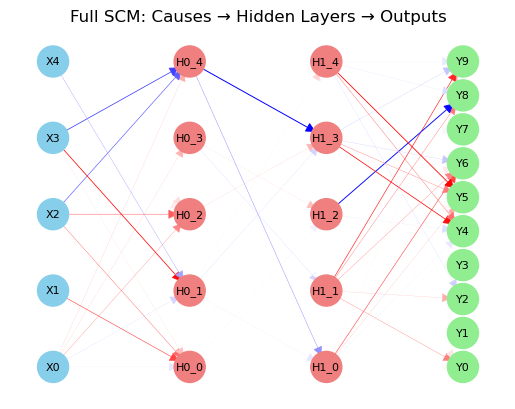

In [179]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch
from matplotlib import cm
from matplotlib.colors import Normalize

def visualize_full_scm(scm):
    """
    Visualize the full SCM MLP:
    Causes -> Hidden layers -> Outputs
    Edge thickness/color shows weight magnitude.
    """
    G = nx.DiGraph()
    pos = {}
    layer_positions = []

    # 1. Causes
    num_causes = scm.mlp.layers[0].in_features
    causes = [f"X{i}" for i in range(num_causes)]
    G.add_nodes_from(causes)
    layer_positions.append(causes)

    # 2. Hidden layers
    hidden_nodes = []
    for l, layer in enumerate(scm.mlp.layers[:-1]):
        hidden_dim = layer.out_features
        nodes = [f"H{l}_{i}" for i in range(hidden_dim)]
        G.add_nodes_from(nodes)
        hidden_nodes.append(nodes)
        layer_positions.append(nodes)
    hidden_nodes_flat = [n for layer in hidden_nodes for n in layer]

    # 3. Outputs
    num_outputs = scm.mlp.layers[-1].out_features
    outputs = [f"Y{i}" for i in range(num_outputs)]
    G.add_nodes_from(outputs)
    layer_positions.append(outputs)

    # Build edges
    previous_layer_nodes = causes
    weights_all = []
    for l, layer in enumerate(scm.mlp.layers):
        weight = layer.weight.detach().cpu().numpy()
        out_nodes = hidden_nodes[l] if l < len(scm.mlp.layers) - 1 else outputs
        for i, target in enumerate(out_nodes):
            for j, src in enumerate(previous_layer_nodes):
                w = weight[i, j]
                if abs(w) > 1e-5:
                    G.add_edge(src, target, weight=w)
                    weights_all.append(w)
        previous_layer_nodes = out_nodes

    weights_all = np.array(weights_all)
    # Layout positions
    for idx, layer_nodes in enumerate(layer_positions):
        y_pos = np.linspace(0, 1, len(layer_nodes))
        for i, node in enumerate(layer_nodes):
            pos[node] = (idx, y_pos[i])

    # Draw nodes
    colors = ['skyblue'] * num_causes + ['lightcoral'] * len(hidden_nodes_flat) + ['lightgreen'] * num_outputs
    nx.draw_networkx_nodes(G, pos, node_size=500, node_color=colors)

    # Draw edges
    edges = G.edges(data=True)
    edge_colors = [d['weight'] for (_, _, d) in edges]
    edge_weights = [abs(d['weight'])*3 for (_, _, d) in edges]
    nx.draw_networkx_edges(G, pos, edgelist=edges, width=edge_weights, edge_color=edge_colors, edge_cmap=plt.cm.bwr, arrowsize=15)

    # Draw labels
    nx.draw_networkx_labels(G, pos, font_size=8)

    # Colorbar
    #sm = cm.ScalarMappable(cmap=plt.cm.bwr, norm=Normalize(vmin=-np.max(np.abs(weights_all)), vmax=np.max(np.abs(weights_all))))
    #sm.set_array([])
    #plt.colorbar(sm, label="Weight magnitude")

    plt.title("Full SCM: Causes → Hidden Layers → Outputs")
    plt.axis('off')
    plt.show()
visualize_full_scm(scm)

In [180]:
def get_scm_prior(num_datasets=10, num_features=1, num_points_in_each_dataset=100, hyperparameters=None):
    """
    A single call generates data from the same SCM but the causes and effects vary across the samples. 
    The structure is same but the sampling of nodes from the SCM graph differ within the same call.
    """
    if hyperparameters is None:
        hyperparameters = {
            'activation': 'relu',
            'num_mlp_outputs': 10,
            'output_noise': 0.1,
            'dropout': 0.1,
            'num_layers': 4, 
            'hidden_dim': 32,
            'y_is_effect': False,
            'init_std': 0.1,
            'num_causes': 10,
        }
    
    hyperparameters['y_is_effect'] = np.random.choice([True, False])
    num_outputs=1 # we only focus on scalar regression
    
    model = SCM(num_outputs, num_features, hyperparameters=hyperparameters).to(device)
    causes = torch.randn(num_datasets, num_points_in_each_dataset, hyperparameters['num_causes'], device=device)
    xs, noisy_ys, target_ys = model(causes)
    return xs, noisy_ys.squeeze(-1), target_ys.squeeze(-1)

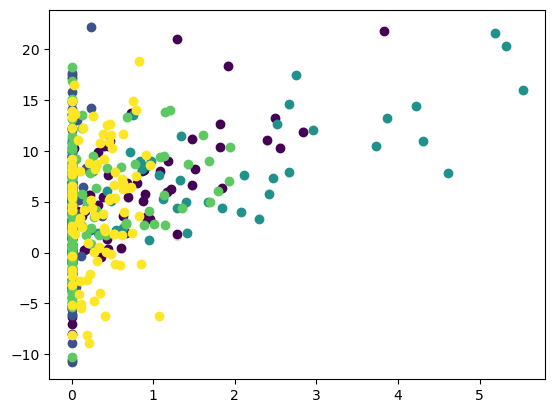

In [196]:
hyperparameters = {
    'activation': 'relu',
    'num_mlp_outputs': 5,
    'output_noise': 0.01,
    'dropout': 0.5,
    'num_layers': 2, 
    'hidden_dim': 64,
    'y_is_effect': False,
    'init_std': 1.0,
    'num_causes': 5
}


num_datasets = 5
colors = mpl.colormaps.get_cmap('viridis').resampled(num_datasets).colors

xs, ys, target_ys = get_scm_prior(num_datasets=num_datasets, num_features=1, hyperparameters=hyperparameters)
for dataset_index in range(num_datasets):
    color = colors[dataset_index].reshape(1,-1)
    plt.scatter(xs[dataset_index], ys[dataset_index], c=color)
    plt.scatter(xs[dataset_index], target_ys[dataset_index], c=color, alpha=0.1)